# Supermarket Sales Analysis

**Author:** Ayisha Mariyam  
**Project Type:** Retail Data Analysis  
**Tools Used:** Python, Pandas, Matplotlib, Seaborn  

---

## Project Objective

The objective of this project is to analyze supermarket sales data to understand:

- Sales patterns
- Customer behavior
- Product performance
- Payment preferences

The analysis will help generate actionable insights that businesses can use to improve sales strategies and operational efficiency.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("Libraries loaded successfully")

Libraries loaded successfully


## Loading the Dataset

The dataset contains supermarket transaction data including:

- Product information
- Customer details
- Payment methods
- Sales amounts

In [2]:
df = pd.read_csv(r"E:\VS CODE\The Developer's Arena Internship 6 months\Month 2\Datasets\supermarket_sales.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


## Preview the Dataset

Viewing the first five rows helps us understand the structure of the dataset.

In [3]:
df.head()

,Invoice_ID,Branch,City,Customer_Type,Gender,Product_Line,Unit_Price,Quantity,Tax,Total,Date,Time,Payment,Rating
0,INV000001,B,Mandalay,Member,Male,Food & Beverages,69.36,3,7.28,119.58,2023-08-08,18:54,Credit card,8.4
1,INV000002,C,Mandalay,Member,Female,Food & Beverages,35.25,1,6.62,137.13,2023-02-09,18:44,Credit card,4.3
2,INV000003,C,Naypyitaw,Normal,Female,Fashion Accessories,57.56,8,4.66,490.48,2023-08-24,16:16,Cash,9.6
3,INV000004,B,Naypyitaw,Member,Female,Food & Beverages,16.60,5,8.57,142.54,2023-02-09,11:35,Cash,4.5
4,INV000005,C,Yangon,Normal,Female,Food & Beverages,49.07,1,3.70,24.43,2023-07-04,8:56,Credit card,5.8


## Dataset Shape

This tells us the number of rows and columns in the dataset.

In [4]:
df.shape

(2000, 14)

## Dataset Information

This provides details about:

- Column names
- Data types
- Missing values

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Invoice_ID     2000 non-null   str    
 1   Branch         2000 non-null   str    
 2   City           2000 non-null   str    
 3   Customer_Type  2000 non-null   str    
 4   Gender         2000 non-null   str    
 5   Product_Line   2000 non-null   str    
 6   Unit_Price     2000 non-null   float64
 7   Quantity       2000 non-null   int64  
 8   Tax            2000 non-null   float64
 9   Total          2000 non-null   float64
 10  Date           2000 non-null   str    
 11  Time           2000 non-null   str    
 12  Payment        2000 non-null   str    
 13  Rating         2000 non-null   float64
dtypes: float64(4), int64(1), str(9)
memory usage: 218.9 KB


## Statistical Summary

The describe() function provides summary statistics such as:

- Mean
- Standard deviation
- Minimum values
- Maximum values

In [6]:
df.describe()

,Unit_Price,Quantity,Tax,Total,Rating
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000
mean,55.258490,5.0330,5.512745,259.640345,6.957600
std,25.813536,2.6087,2.582829,138.930861,1.730534
min,10.010000,1.0000,1.000000,20.370000,4.000000
25%,33.615000,3.0000,3.317500,137.872500,5.400000
50%,55.610000,5.0000,5.440000,258.040000,6.950000
75%,77.500000,7.0000,7.742500,386.937500,8.400000
max,99.920000,9.0000,10.000000,499.910000,10.000000


## Data Quality Check

Before analysis, we verify the dataset for:

- Missing values
- Duplicate records

In [7]:
# Check missing values

df.isnull().sum()

Invoice_ID       0
Branch           0
City             0
Customer_Type    0
Gender           0
Product_Line     0
Unit_Price       0
Quantity         0
Tax              0
Total            0
Date             0
Time             0
Payment          0
Rating           0
dtype: int64

In [8]:
# Check duplicate rows

df.duplicated().sum()

np.int64(0)

## Data Cleaning

To prepare the dataset for analysis we perform:

1. Convert Date column to datetime
2. Convert Time column to datetime
3. Verify column data types

In [9]:
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time'])

df.dtypes

C:\Users\HP\AppData\Local\Temp\ipykernel_86260\2633778722.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'])


Invoice_ID                  str
Branch                      str
City                        str
Customer_Type               str
Gender                      str
Product_Line                str
Unit_Price              float64
Quantity                  int64
Tax                     float64
Total                   float64
Date             datetime64[us]
Time             datetime64[us]
Payment                     str
Rating                  float64
dtype: object

## Feature Engineering

To analyze trends more effectively, we create additional columns:

- Month
- Day of week
- Hour of transaction
- Daily sales
- Best products
- Customer spending patterns

In [10]:
print(df.columns)

Index(['Invoice_ID', 'Branch', 'City', 'Customer_Type', 'Gender',
       'Product_Line', 'Unit_Price', 'Quantity', 'Tax', 'Total', 'Date',
       'Time', 'Payment', 'Rating'],
      dtype='str')


In [11]:
df.head(3)

,Invoice_ID,Branch,City,Customer_Type,Gender,Product_Line,Unit_Price,Quantity,Tax,Total,Date,Time,Payment,Rating
0,INV000001,B,Mandalay,Member,Male,Food & Beverages,69.36,3,7.28,119.58,2023-08-08,2026-03-12 18:54:00,Credit card,8.4
1,INV000002,C,Mandalay,Member,Female,Food & Beverages,35.25,1,6.62,137.13,2023-02-09,2026-03-12 18:44:00,Credit card,4.3
2,INV000003,C,Naypyitaw,Normal,Female,Fashion Accessories,57.56,8,4.66,490.48,2023-08-24,2026-03-12 16:16:00,Cash,9.6


In [12]:
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day_name()
df['Hour'] = df['Time'].dt.hour

df.head()

,Invoice_ID,Branch,City,Customer_Type,Gender,Product_Line,Unit_Price,Quantity,Tax,Total,Date,Time,Payment,Rating,Month,Day,Hour
0,INV000001,B,Mandalay,Member,Male,Food & Beverages,69.36,3,7.28,119.58,2023-08-08,2026-03-12 18:54:00,Credit card,8.4,8,Tuesday,18
1,INV000002,C,Mandalay,Member,Female,Food & Beverages,35.25,1,6.62,137.13,2023-02-09,2026-03-12 18:44:00,Credit card,4.3,2,Thursday,18
2,INV000003,C,Naypyitaw,Normal,Female,Fashion Accessories,57.56,8,4.66,490.48,2023-08-24,2026-03-12 16:16:00,Cash,9.6,8,Thursday,16
3,INV000004,B,Naypyitaw,Member,Female,Food & Beverages,16.60,5,8.57,142.54,2023-02-09,2026-03-12 11:35:00,Cash,4.5,2,Thursday,11
4,INV000005,C,Yangon,Normal,Female,Food & Beverages,49.07,1,3.70,24.43,2023-07-04,2026-03-12 08:56:00,Credit card,5.8,7,Tuesday,8


## Total Sales Overview

We calculate the overall sales and number of transactions.

In [13]:
total_sales = df['Total'].sum()
transactions = df.shape[0]

print("Total Sales:", total_sales)
print("Total Transactions:", transactions)

Total Sales: 519280.69
Total Transactions: 2000


## Sales by Product Line

This analysis identifies which product categories generate the highest revenue.

In [14]:
product_sales = df.groupby('Product_Line')['Total'].sum().sort_values(ascending=False)

product_sales

Product_Line
Health & Beauty           96970.32
Sports & Travel           91177.89
Electronic Accessories    88995.19
Home & Lifestyle          86351.63
Food & Beverages          78233.94
Fashion Accessories       77551.72
Name: Total, dtype: float64

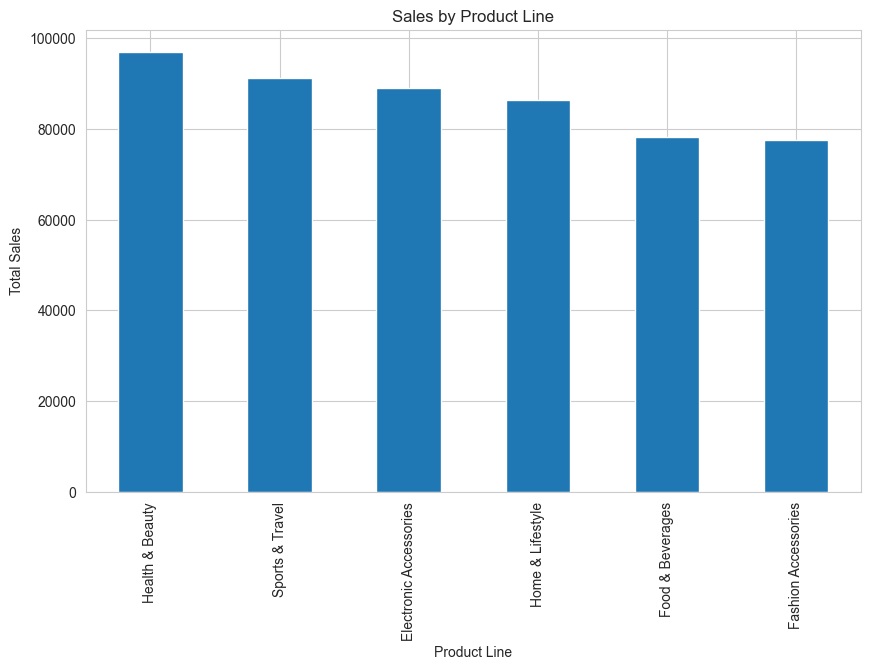

In [15]:
plt.figure(figsize=(10,6))

product_sales.plot(kind='bar')

plt.title("Sales by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Total Sales")

plt.show()

## Sales by Branch

We analyze which store branch generates the most revenue.

In [16]:
branch_sales = df.groupby('Branch')['Total'].sum()

branch_sales

Branch
A    179047.93
B    180821.79
C    159410.97
Name: Total, dtype: float64

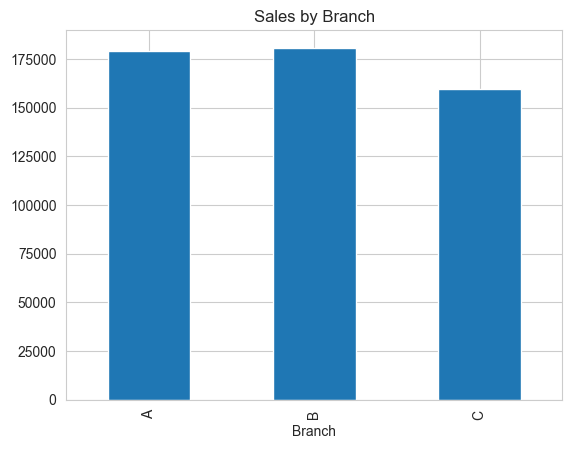

In [17]:
branch_sales.plot(kind='bar')

plt.title("Sales by Branch")

plt.show()

## Customer Type Analysis

This analysis compares sales generated by different customer groups.

In [18]:
customer_sales = df.groupby('Customer_Type')['Total'].sum()

customer_sales

Customer_Type
Member    261919.34
Normal    257361.35
Name: Total, dtype: float64

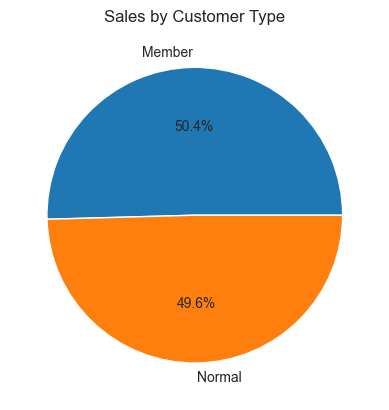

In [19]:
customer_sales.plot(kind='pie', autopct='%1.1f%%')

plt.title("Sales by Customer Type")

plt.ylabel("")

plt.show()

## Payment Method Analysis

Understanding payment preferences helps businesses improve checkout systems.

In [20]:
payment_counts = df['Payment'].value_counts()

payment_counts

Payment
Ewallet        720
Cash           658
Credit card    622
Name: count, dtype: int64

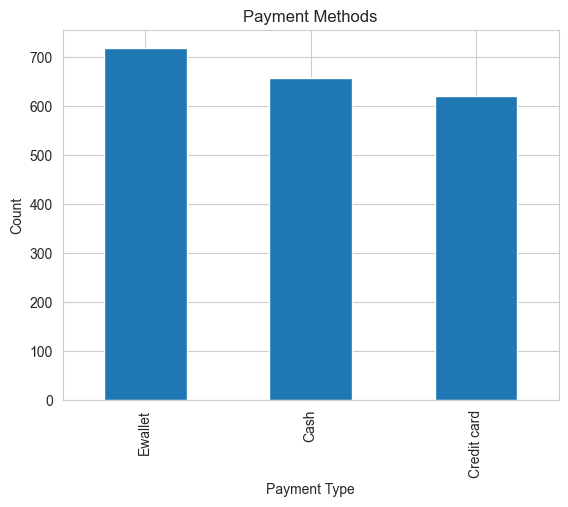

In [21]:
payment_counts.plot(kind='bar')

plt.title("Payment Methods")
plt.xlabel("Payment Type")
plt.ylabel("Count")

plt.show()

## Daily Sales Trend

Analyzing daily sales helps identify demand patterns over time.

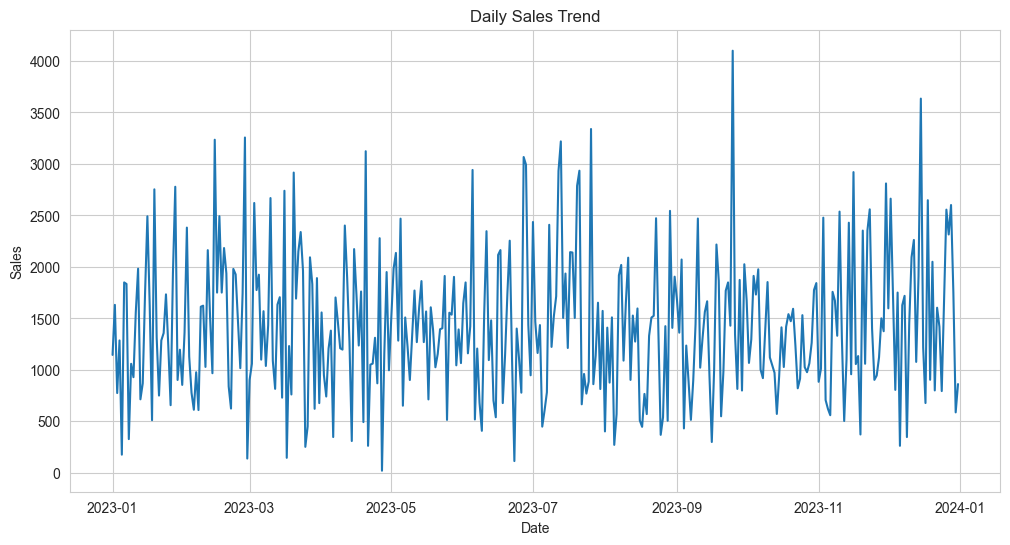

In [22]:
daily_sales = df.groupby('Date')['Total'].sum()

plt.figure(figsize=(12,6))

plt.plot(daily_sales)

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

## Correlation Analysis

Correlation helps identify relationships between numerical variables.

In [23]:
corr = df[['Unit_Price','Quantity','Tax','Total','Rating']].corr()

corr

,Unit_Price,Quantity,Tax,Total,Rating
Unit_Price,1.000000,0.021547,-0.006407,0.004670,-0.013828
Quantity,0.021547,1.000000,-0.021480,-0.012459,-0.015680
Tax,-0.006407,-0.021480,1.000000,-0.004217,-0.016355
Total,0.004670,-0.012459,-0.004217,1.000000,-0.009223
Rating,-0.013828,-0.015680,-0.016355,-0.009223,1.000000


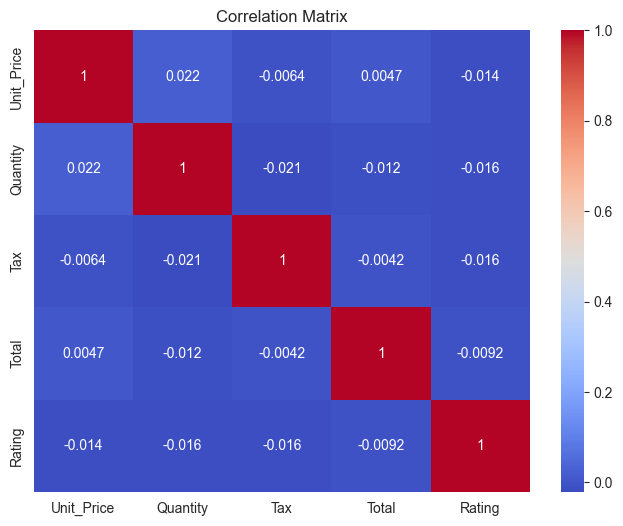

In [24]:
plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

## Customer Rating Distribution

Customer ratings provide insights into customer satisfaction levels.

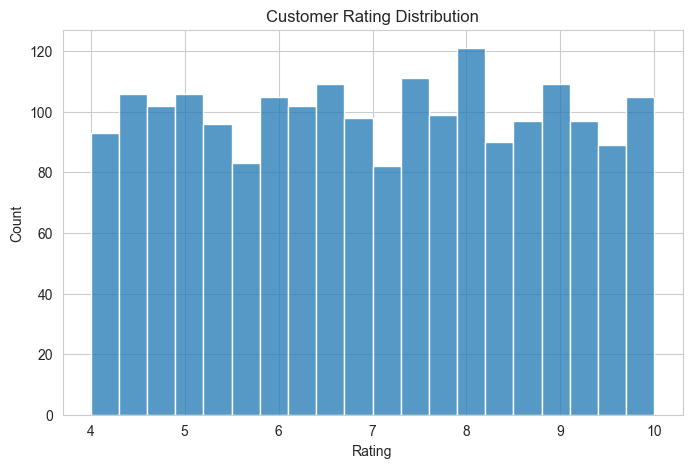

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(df['Rating'], bins=20)

plt.title("Customer Rating Distribution")

plt.show()

# Key Insights

1. Some product lines generate significantly higher revenue.
2. Sales performance varies across branches.
3. Different customer types contribute differently to revenue.
4. Digital payment methods are widely used.
5. Customer ratings are generally high, indicating positive satisfaction.

# Business Recommendations

Based on the analysis:

1. Increase inventory for high-performing product lines.
2. Introduce promotional campaigns in lower-performing branches.
3. Encourage digital payments through loyalty rewards.
4. Improve marketing strategies during peak sales periods.
5. Continue maintaining high customer service standards.

# Conclusion

This project demonstrates how data analysis can help retail businesses understand sales trends, customer behavior, and product performance.

Using Python and data visualization tools, we generated insights that can support data-driven decision-making and improve overall business performance.